In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:


data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape


((16512, 8), (16512, 1))

In [4]:
def predict(X, W):
    return np.dot(X, W)

def cost(X, y, W):
    m = len(y)
    return (1/(2*m)) * np.sum((predict(X, W) - y)**2)

In [5]:
def batch_gradient_descent(X, y, lr=0.01, epochs=200):
    m, n = X.shape
    W = np.zeros((n, 1))
    history = []
    for epoch in range(epochs):
        grad = (1/m) * X.T.dot(predict(X, W) - y)
        W -= lr * grad
        history.append(cost(X, y, W))
    return W, history

W_bgd, hist_bgd = batch_gradient_descent(X_train, y_train, lr=0.05, epochs=150)

In [6]:
def stochastic_gradient_descent(X, y, lr=0.01, epochs=15):
    m, n = X.shape
    W = np.zeros((n, 1))
    history = []
    for epoch in range(epochs):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i:i+1]
            grad = xi.T.dot(predict(xi, W) - yi)
            W -= lr * grad
        history.append(cost(X, y, W))
    return W, history

W_sgd, hist_sgd = stochastic_gradient_descent(X_train, y_train, lr=0.01, epochs=40)

/tmp/ipykernel_2144/2146088657.py:6: RuntimeWarning: overflow encountered in square
  return (1/(2*m)) * np.sum((predict(X, W) - y)**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [7]:
def mini_batch_gradient_descent(X, y, lr=0.02, epochs=60, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    history = []
    for epoch in range(epochs):
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]
        for i in range(0, m, batch_size):
            xb = X_shuffled[i:i+batch_size]
            yb = y_shuffled[i:i+batch_size]
            grad = (1/len(yb)) * xb.T.dot(predict(xb, W) - yb)
            W -= lr * grad
        history.append(cost(X, y, W))
    return W, history

W_mbgd, hist_mbgd = mini_batch_gradient_descent(X_train, y_train)

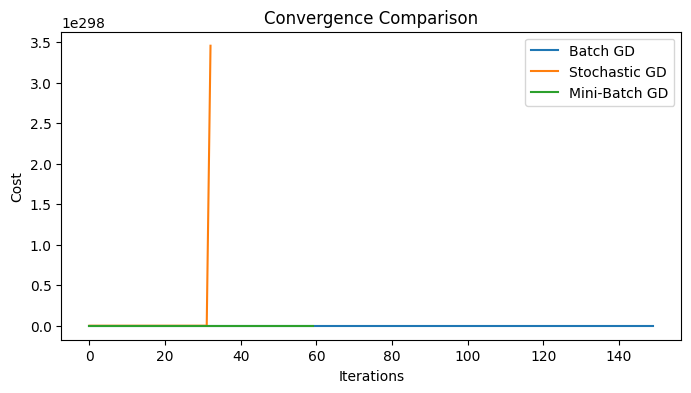

In [8]:
plt.figure(figsize=(8,4))
plt.plot(hist_bgd, label="Batch GD")
plt.plot(hist_sgd, label="Stochastic GD")
plt.plot(hist_mbgd, label="Mini‑Batch GD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence Comparison")
plt.legend()
plt.show()


In [9]:
def rmse(X, y, W):
    preds = predict(X, W)
    return np.sqrt(mean_squared_error(y, preds))

rmse_bgd = rmse(X_test, y_test, W_bgd)
rmse_sgd = rmse(X_test, y_test, W_sgd)
rmse_mbgd = rmse(X_test, y_test, W_mbgd)

rmse_bgd, rmse_sgd, rmse_mbgd

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


(np.float64(2.2084655133167086),
 np.float64(inf),
 np.float64(2.215895486889585))